In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as scp
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import os

file_pulito = os.path.join('./data','df_quasi_selezionato.csv')
df = pd.read_csv(file_pulito)

In [48]:
df['FULL_origin_port_TO_logistic_hub_TO_city_customer'].value_counts()

FULL_origin_port_TO_logistic_hub_TO_city_customer
RotterdamVenloMilan       1146
RotterdamVenloBerlin      1133
RotterdamVenloMadrid      1077
RotterdamHamburgBerlin    1041
RotterdamHamburgMilan     1008
                          ... 
BarcelonaNoHubNaples         1
BarcelonaNoHubTurin          1
BarcelonaNoHubLisbon         1
BarcelonaNoHubBremen         1
BarcelonaNoHubBudapest       1
Name: count, Length: 802, dtype: int64

In [3]:
df.shape

(114158, 36)

In [4]:
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [5]:
df = df.drop(columns=['order_id'])

In [6]:
from sklearn.model_selection import train_test_split


df_train, df_validation = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42
)

In [7]:
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=['late_order'])
y = df_train['late_order']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
   
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 4],   
    random_seed=42,
    verbose=False
)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# 2. Replace NaNs in categorical
X_train[cat_cols] = X_train[cat_cols].fillna("Unknown").astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown").astype(str)

# 3. Convert to indices
cat_indices = [X_train.columns.get_loc(c) for c in cat_cols]

# 4. Fit model
model.fit(X_train, y_train, cat_features=cat_indices)

In [9]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"\n ROC-AUC: {auc:.4f}")


 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.74      0.81     13895
           1       0.48      0.75      0.58      4371

    accuracy                           0.74     18266
   macro avg       0.69      0.75      0.70     18266
weighted avg       0.80      0.74      0.76     18266


 ROC-AUC: 0.8284


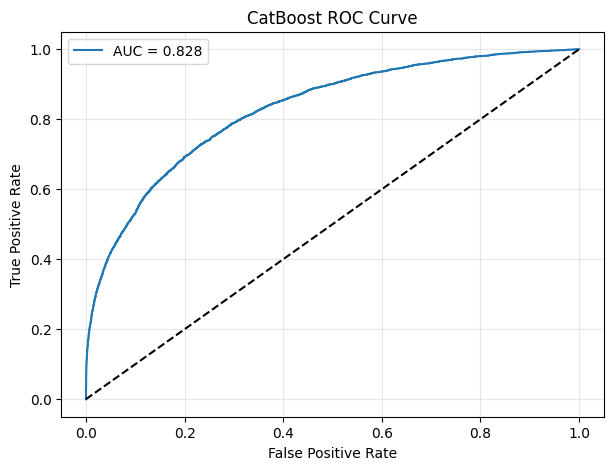

In [10]:
fpr, tpr, thr = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("CatBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

THRESHOLD: 0.5
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.905     0.739     0.813     13895
           1      0.475     0.753     0.583      4371

    accuracy                          0.742     18266
   macro avg      0.690     0.746     0.698     18266
weighted avg      0.802     0.742     0.758     18266


Confusion Matrix:
[[10262  3633]
 [ 1078  3293]]


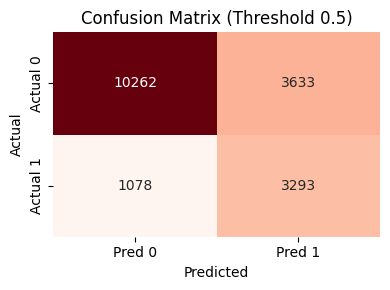

THRESHOLD: 0.45
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.918     0.680     0.781     13895
           1      0.442     0.806     0.571      4371

    accuracy                          0.710     18266
   macro avg      0.680     0.743     0.676     18266
weighted avg      0.804     0.710     0.730     18266


Confusion Matrix:
[[9442 4453]
 [ 849 3522]]


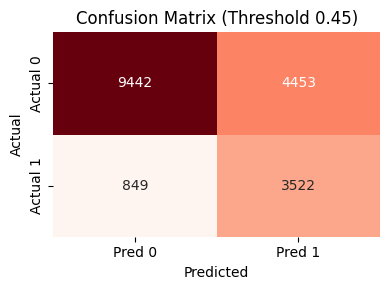

THRESHOLD: 0.4
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.928     0.616     0.740     13895
           1      0.410     0.847     0.552      4371

    accuracy                          0.671     18266
   macro avg      0.669     0.732     0.646     18266
weighted avg      0.804     0.671     0.695     18266


Confusion Matrix:
[[8562 5333]
 [ 669 3702]]


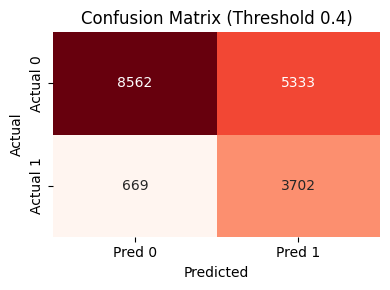

THRESHOLD: 0.35
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.938     0.543     0.688     13895
           1      0.379     0.886     0.531      4371

    accuracy                          0.625     18266
   macro avg      0.658     0.714     0.609     18266
weighted avg      0.804     0.625     0.650     18266


Confusion Matrix:
[[7547 6348]
 [ 500 3871]]


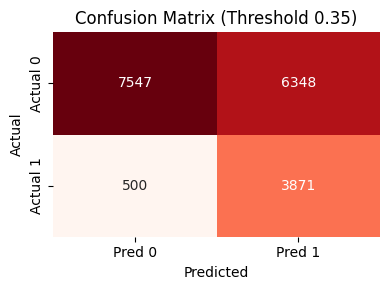

THRESHOLD: 0.3
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.946     0.464     0.623     13895
           1      0.349     0.915     0.506      4371

    accuracy                          0.572     18266
   macro avg      0.648     0.690     0.564     18266
weighted avg      0.803     0.572     0.595     18266


Confusion Matrix:
[[6448 7447]
 [ 371 4000]]


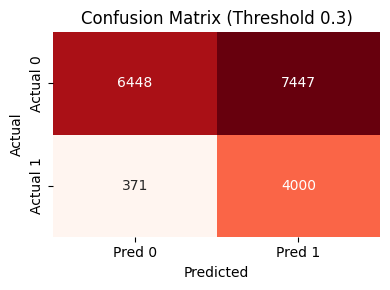

THRESHOLD: 0.25
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.955     0.374     0.537     13895
           1      0.322     0.943     0.480      4371

    accuracy                          0.510     18266
   macro avg      0.638     0.659     0.509     18266
weighted avg      0.803     0.510     0.524     18266


Confusion Matrix:
[[5197 8698]
 [ 247 4124]]


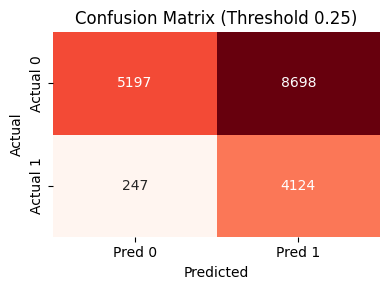

In [11]:
from sklearn.metrics import (
    recall_score, 
    precision_score, 
    classification_report, 
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)
    
    print("="*70)
    print(f"THRESHOLD: {th}")
    print("-"*70)

    # Classification report
    print(classification_report(y_test, y_pred, digits=3))
    
    # Recall & Precision
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(f"Confusion Matrix (Threshold {th})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

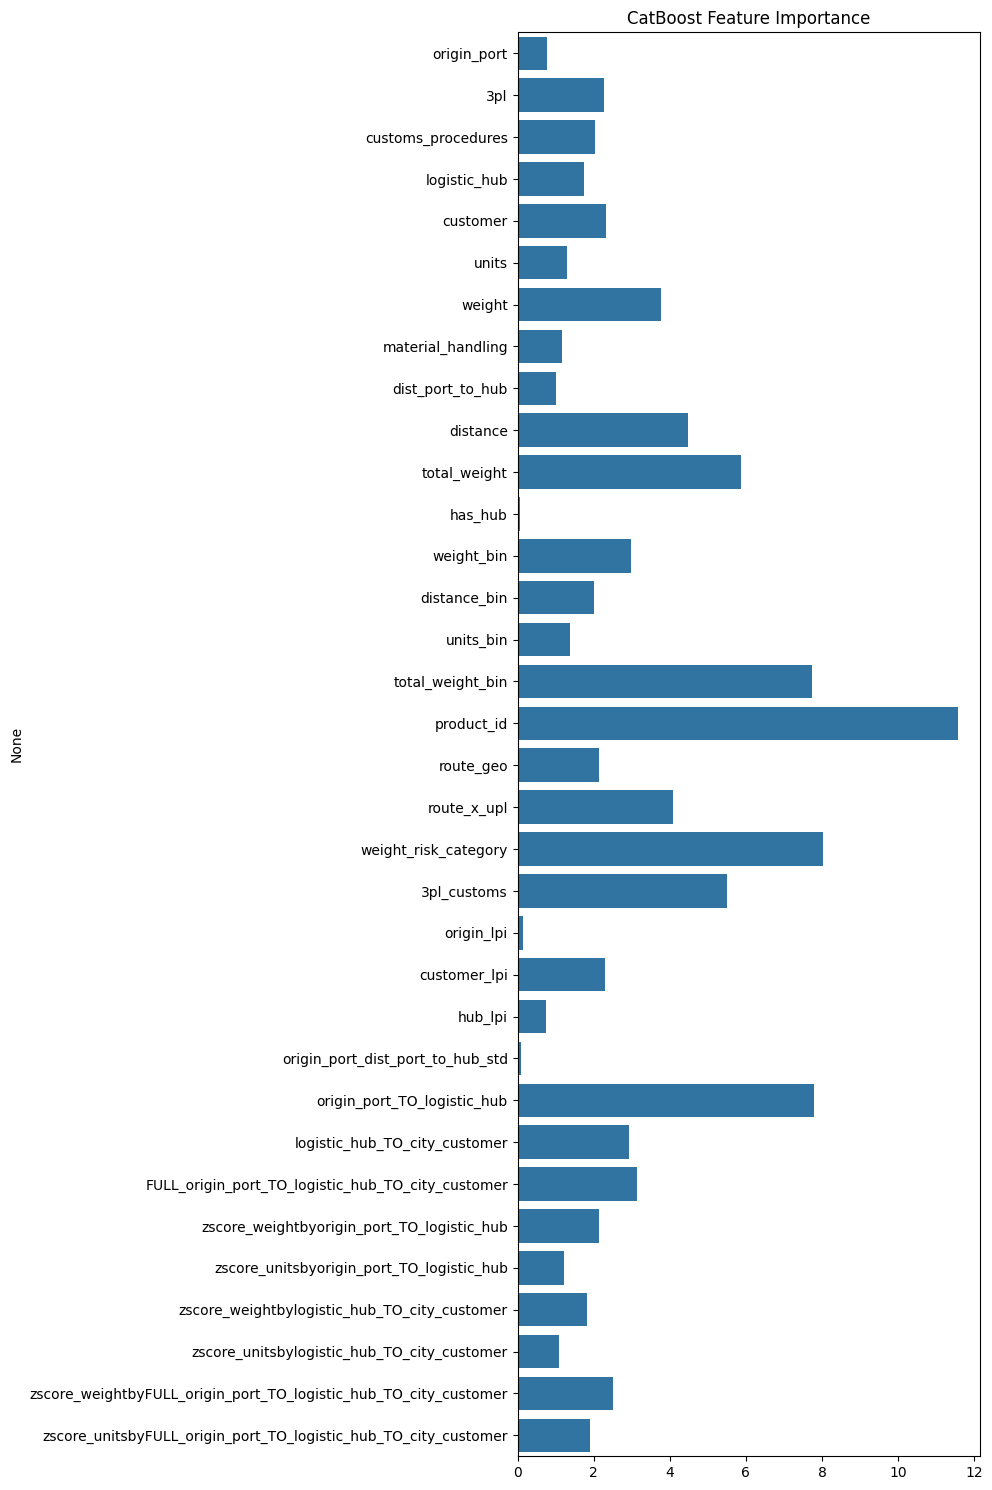

In [12]:
importances = model.get_feature_importance()
feat_names = X_train.columns

plt.figure(figsize=(10,15))
sns.barplot(
    x=importances,
    y=feat_names,
    orient="h"
)
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

In [13]:
df_train.columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'units', 'late_order', 'weight', 'material_handling',
       'dist_port_to_hub', 'distance', 'total_weight', 'has_hub', 'weight_bin',
       'distance_bin', 'units_bin', 'total_weight_bin', 'product_id',
       'route_geo', 'route_x_upl', 'weight_risk_category', '3pl_customs',
       'origin_lpi', 'customer_lpi', 'hub_lpi',
       'origin_port_dist_port_to_hub_std', 'origin_port_TO_logistic_hub',
       'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_weightbyorigin_port_TO_logistic_hub',
       'zscore_unitsbyorigin_port_TO_logistic_hub',
       'zscore_weightbylogistic_hub_TO_city_customer',
       'zscore_unitsbylogistic_hub_TO_city_customer',
       'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer'],
      dtype='object')

### Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score



# Parameter search space including class weights
param_dist = {
    "iterations": [600, 800],
    "learning_rate": [0.05, 0.03, 0.02, 0.01],
    "depth": [6, 7, 8, 9],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "bagging_temperature": [0, 0.5, 1, 2],
    "border_count": [128, 254],
    "class_weights": [
        [1, 2],
        [1, 3],
        [1, 4],
        [1, 5],  
    ]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,                    
    scoring= "recall",            
    cv=3,
    verbose=2,
    n_jobs=-1,
)

random_search.fit(X_train, y_train, cat_features=cat_cols)

# Best model
best_model = random_search.best_estimator_

print("Best params:", random_search.best_params_)
print("Best recall:", random_search.best_score_)

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [16]:
1/0.25

4.0

In [ ]:
fpr, tpr, thr = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("CatBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = best_model.predict(X_test)



print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0 (On Time)", "Pred 1 (Late)"],
    yticklabels=["Actual 0 (On Time)", "Actual 1 (Late)"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

ap = average_precision_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', linewidth=2, label=f"PR Curve (AP = {ap:.3f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision–Recall Curve", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

for th in thresholds:
    y_pred = (y_proba >= th).astype(int)
    
    print("="*70)
    print(f"THRESHOLD: {th}")
    print("-"*70)

    # Classification report
    print(classification_report(y_test, y_pred, digits=3))
    
    # Recall & Precision
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(f"Confusion Matrix (Threshold {th})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

In [ ]:
importances = best_model.get_feature_importance()


feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})


feat_imp = feat_imp.sort_values("importance", ascending=False)

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(20),
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title("Top 20 Most Important Features (CatBoost)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Model without bin

In [23]:
X = df_train.drop(columns=['late_order', 'distance_bin', 'weight_bin', 'units_bin', 'total_weight_bin', 'product_id'])
y = df_train['late_order']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 800, 'depth': 6, 'class_weights': [1, 5], 'border_count': 254, 'bagging_temperature': 1

In [ ]:
model_opt = CatBoostClassifier(
   
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 5],   
    random_seed=42,
    learning_rate=0.01,
    l2_leaf_reg=5,
    iterations=800,
    depth=6,
    border_count=254,
    bagging_temperature=1,
    verbose=False
)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

X_train[cat_cols] = X_train[cat_cols].fillna("Unknown").astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown").astype(str)

cat_indices = [X_train.columns.get_loc(c) for c in cat_cols]

# Fit
model_opt.fit(X_train, y_train, cat_features=cat_indices)

In [25]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred = model_opt.predict(X_test)
y_prob = model_opt.predict_proba(X_test)[:, 1]

print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"\n ROC-AUC: {auc:.4f}")


 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.61      0.73     13895
           1       0.40      0.83      0.54      4371

    accuracy                           0.66     18266
   macro avg       0.66      0.72      0.64     18266
weighted avg       0.80      0.66      0.69     18266


 ROC-AUC: 0.8131


In [26]:
importances = model_opt.get_feature_importance()


feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})


feat_imp = feat_imp.sort_values("importance", ascending=False)

In [27]:
feat_imp.head(10)

,feature,importance
10,total_weight,27.605
20,origin_port_TO_logistic_hub,13.067
14,weight_risk_category,9.170
15,3pl_customs,7.168
6,weight,7.005
13,route_x_upl,4.042
22,FULL_origin_port_TO_logistic_hub_TO_city_customer,3.593
23,zscore_weightbyorigin_port_TO_logistic_hub,3.574
9,distance,3.255
21,logistic_hub_TO_city_customer,2.392


C:\Users\gaiag\AppData\Local\Temp\ipykernel_19496\3037153250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


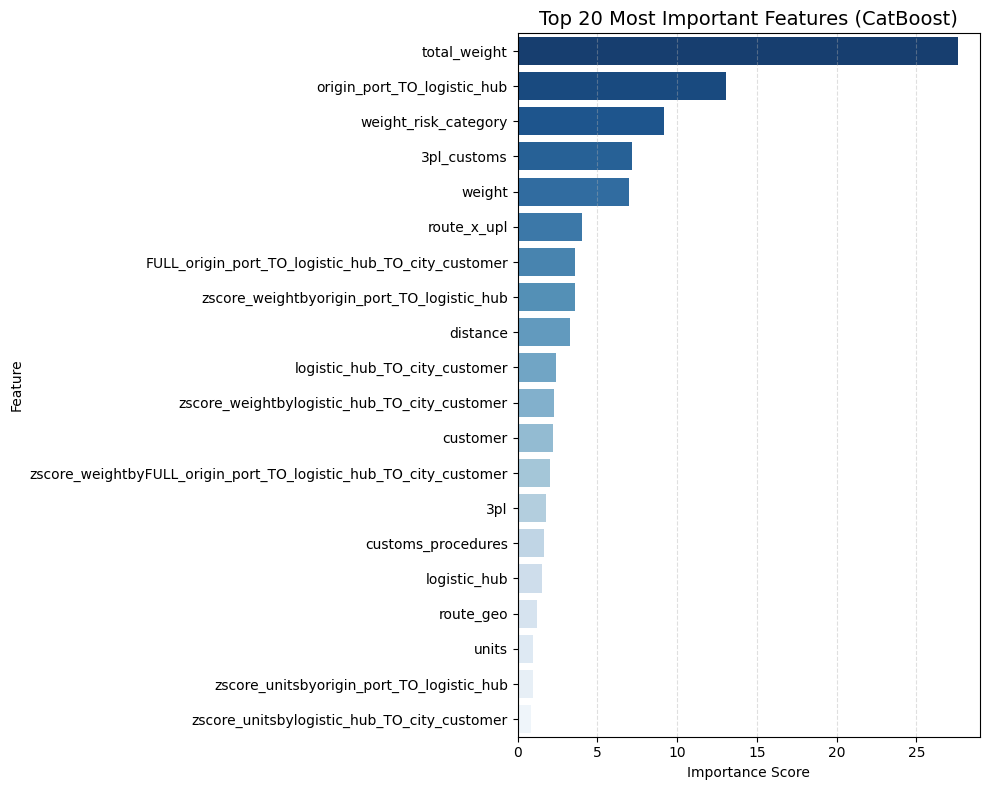

In [28]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feat_imp.head(20),
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title("Top 20 Most Important Features (CatBoost)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

def optimize_threshold_cost(
    y_true,
    y_prob,
    cost_fp=1.0,
    cost_fn=3.0,
    n_thresholds=200
):
    """
    Find the decision threshold that minimizes expected cost,
    given costs for false positives and false negatives.

    Parameters
    ----------
    y_true : array-like
        True labels (0/1).
    y_prob : array-like
        Predicted probabilities for class 1.
    cost_fp : float
        Cost of a false positive (predict 1, actual 0).
    cost_fn : float
        Cost of a false negative (predict 0, actual 1).
    n_thresholds : int
        Number of thresholds to scan between 0 and 1.

    Returns
    -------
    best_threshold : float
        Threshold that minimizes expected cost.
    results : pandas.DataFrame
        Table with threshold, metrics, confusion counts, and cost.
    """

    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    records = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    N = len(y_true)

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = (tp + tn) / N

        # cost per sample
        cost = (fp * cost_fp + fn * cost_fn) / N

        records.append({
            "threshold": th,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "accuracy": acc,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "cost": cost
        })

    results = pd.DataFrame(records)
    best_idx = results["cost"].idxmin()
    best_threshold = results.loc[best_idx, "threshold"]

    return best_threshold, results.sort_values("threshold").reset_index(drop=True)

In [ ]:
y_prob = model_opt.predict_proba(X_test)[:, 1]

best_th, cost_table = optimize_threshold_cost(
    y_test,
    y_prob,
    cost_fp=1.0,
    cost_fn=4.8,
    n_thresholds=200
)

print("Best threshold (cost-based):", round(best_th, 3))

row = cost_table.loc[cost_table["threshold"].sub(best_th).abs().idxmin()]
row

Best threshold (cost-based): 0.473


threshold      0.473
precision      0.388
recall         0.855
f1             0.534
accuracy       0.642
tp          3739.000
fp          5900.000
fn           632.000
tn          7995.000
cost           0.489
Name: 94, dtype: float64

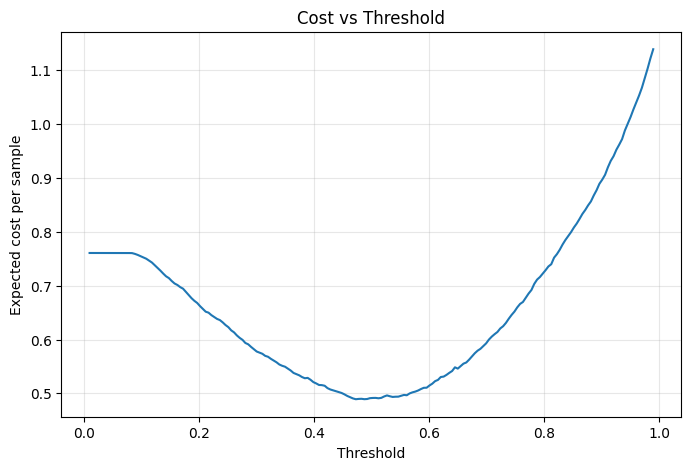

In [31]:


plt.figure(figsize=(8, 5))
plt.plot(cost_table["threshold"], cost_table["cost"])
plt.xlabel("Threshold")
plt.ylabel("Expected cost per sample")
plt.title("Cost vs Threshold")
plt.grid(True, alpha=0.3)
plt.show()

### Validation

In [32]:
X_val = df_validation.drop(columns=["late_order", 'distance_bin', 'weight_bin', 'units_bin', 'total_weight_bin', 'product_id'])
y_val = df_validation["late_order"]

In [33]:
y_val_prob = model_opt.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

VALIDATION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0      0.919     0.619     0.740     17354
           1      0.406     0.826     0.545      5478

    accuracy                          0.669     22832
   macro avg      0.662     0.723     0.642     22832
weighted avg      0.796     0.669     0.693     22832


VALIDATION CONFUSION MATRIX:
[[10745  6609]
 [  953  4525]]


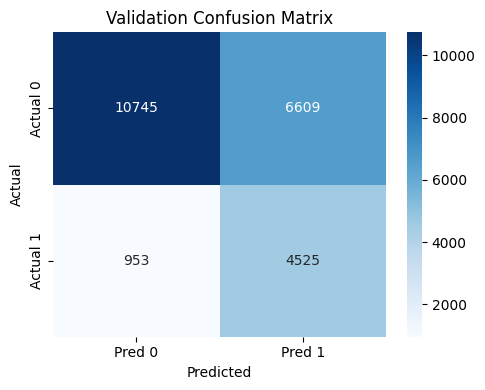

In [34]:
print("VALIDATION CLASSIFICATION REPORT:")
print(classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
print("\nVALIDATION CONFUSION MATRIX:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

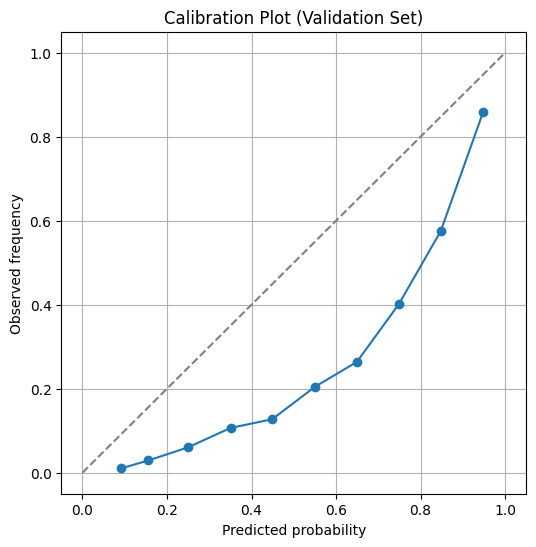

In [35]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, y_val_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Plot (Validation Set)")
plt.grid(True)
plt.show()

In [36]:
X_val.columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'units', 'weight', 'material_handling', 'dist_port_to_hub', 'distance',
       'total_weight', 'has_hub', 'route_geo', 'route_x_upl',
       'weight_risk_category', '3pl_customs', 'origin_lpi', 'customer_lpi',
       'hub_lpi', 'origin_port_dist_port_to_hub_std',
       'origin_port_TO_logistic_hub', 'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_weightbyorigin_port_TO_logistic_hub',
       'zscore_unitsbyorigin_port_TO_logistic_hub',
       'zscore_weightbylogistic_hub_TO_city_customer',
       'zscore_unitsbylogistic_hub_TO_city_customer',
       'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer'],
      dtype='object')

In [37]:
X_val.shape

(22832, 29)

In [ ]:
from catboost import CatBoostClassifier
import joblib

model_opt.save_model("catboost_late_model.cbm")

feature_cols = [
    'origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
    'units', 'weight', 'material_handling', 'dist_port_to_hub', 'distance',
    'total_weight', 'has_hub', 'route_geo', 'route_x_upl', 'weight_class',
    'weight_risk_category', '3pl_customs', 'origin_lpi', 'customer_lpi',
    'hub_lpi', 'origin_port_dist_port_to_hub_std',
    'origin_port_TO_logistic_hub', 'logistic_hub_TO_city_customer',
    'FULL_origin_port_TO_logistic_hub_TO_city_customer',
    'zscore_weightbyorigin_port_TO_logistic_hub',
    'zscore_unitsbyorigin_port_TO_logistic_hub',
    'zscore_weightbylogistic_hub_TO_city_customer',
    'zscore_unitsbylogistic_hub_TO_city_customer',
    'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
    'zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer'
]

joblib.dump(feature_cols, "model_features.pkl")

['model_features.pkl']

In [39]:
bins = pd.qcut(df["weight"], q=4, retbins=True)[1]
print(bins)

[ 136.  901. 1243. 1639. 2876.]


In [ ]:
# ORDINI ON-TIME: 

y_pred_test = model_opt.predict(X_test)
y_prob_test = model_opt.predict_proba(X_test)[:,1]


df_eval = X_test.copy()
df_eval["actual"] = y_test.values
df_eval["pred"] = y_pred_test
df_eval["prob_late"] = y_prob_test


df_on_time = df_eval[df_eval["pred"] == 0]

print("Numero di ordini previsti ON TIME:", len(df_on_time))
df_on_time.head()

Numero di ordini previsti ON TIME: 9226


,origin_port,3pl,customs_procedures,logistic_hub,customer,units,weight,material_handling,dist_port_to_hub,distance,...,FULL_origin_port_TO_logistic_hub_TO_city_customer,zscore_weightbyorigin_port_TO_logistic_hub,zscore_unitsbyorigin_port_TO_logistic_hub,zscore_weightbylogistic_hub_TO_city_customer,zscore_unitsbylogistic_hub_TO_city_customer,zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer,zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer,actual,pred,prob_late
86649,Barcelona,v_002,DTD,Venlo,Munich,478,975.000,5.000,1153.418,1685.895,...,BarcelonaVenloMunich,-0.555,-0.111,-0.569,-0.112,-0.593,-0.093,0,0,0.265
4884,Rotterdam,v_004,DTP,Hamburg,Munich,535,1281.000,5.000,414.449,1026.732,...,RotterdamHamburgMunich,0.021,0.723,0.006,0.731,-0.011,0.692,0,0,0.254
8423,Athens,v_002,CRF,Hamburg,Berlin,503,1623.000,2.000,2025.221,2279.915,...,AthensHamburgBerlin,0.691,0.254,0.732,0.260,0.726,0.234,0,0,0.357
60889,Rotterdam,v_002,CRF,Liege,Madrid,453,638.000,3.000,161.562,1507.356,...,RotterdamLiegeMadrid,-1.226,-0.455,-1.246,-0.434,-1.340,-0.393,1,0,0.301
54520,Rotterdam,v_004,DTD,Warsaw,Rome,422,836.000,5.000,1135.645,2455.325,...,RotterdamWarsawRome,-0.836,-0.896,-0.776,-0.854,-0.742,-0.849,0,0,0.361
